# Actigram Analysis


---

#### Snapshot of eGFP ABA analysis (cohort 1, 5/2025) for Binder.
**Updated:** 2026-06-04, JR

---

## Setup

In [17]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

In [18]:
LIGHT_CYCLES = [
    (0, 12, "yellow"),
    (12, 24, "gray"),
]
DARK_PHASE_COLOR = "gray"

ABA_DATES = pd.date_range(datetime(2026, 4, 23), datetime(2026, 5, 4)).to_list()
ABA_DARK_PHASE_HOURS = 2

CLIP_UPPER = {
    'pir': 12,
    'wheel': 220,
    'other': np.inf,
}

ROW_HEIGHT = {
    'pir': 16,
    'wheel': 250,
    'other': 16,
}

In [19]:
def detect_col_type(col_name: str):
    low = col_name.lower()
    if low.startswith('pir'):
        return 'pir'
    if low.startswith('wh'):
        return 'wheel'
    return 'other'


def sanitize_filename(name: str) -> str:
    return name.replace('/', '_').replace('\\', '_').replace(':', '_')

## Data

In [20]:
def prepare_minute_dfs(
    compiled_csv: str,
    exclusions: dict[str, list[tuple[datetime, datetime]]],
    freq: str = 'min',
    export_dir: str | Path = '/output_by-minute',
) -> dict[str, pd.DataFrame]:
    export_dir = Path(export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)

    raw = pd.read_csv(compiled_csv, dtype=str, header=0)
    raw = raw.loc[:, ~raw.columns.str.contains('^Unnamed', case=False)]
    print(f"Found {len(raw.columns)} sensors: {raw.columns.tolist()[:5]}...")

    rounded = raw.apply(pd.to_datetime, errors='coerce').apply(lambda col: col.dt.floor(freq))
    counts = rounded.apply(lambda col: col.value_counts()).fillna(0)
    counts.index = pd.to_datetime(counts.index)

    global_start = counts.index.min().normalize()
    global_end = counts.index.max().normalize() + pd.Timedelta(days=1) - pd.Timedelta(minutes=1)
    full_idx = pd.date_range(global_start, global_end, freq=freq)

    out = {}
    for col in counts.columns:
        ctype = detect_col_type(col)
        df = counts[[col]].clip(upper=CLIP_UPPER[ctype]).reindex(full_idx, fill_value=0)

        for start, end in exclusions.get(col, []):
            df.loc[start:end, col] = np.nan

        valid = df[col].dropna() > 0
        if valid.any():
            t0 = valid.idxmax()
            t1 = valid[::-1].idxmax()
            df.loc[:t0, col] = np.nan
            df.loc[t1:, col] = np.nan

        df['calendar_date'] = df.index.date
        df['time_decimal'] = df.index.hour + df.index.minute / 60

        safe_col = sanitize_filename(col)
        df.to_csv(export_dir / f"{safe_col}_min_masked.csv")
        out[col] = df

    return out

## Plotting

In [21]:
def time_label(x, pos):
    hour = int(x) % 24
    return f"{hour:02d}:00"


def dark_phase_start_hour(light_cycles=LIGHT_CYCLES, dark_color=DARK_PHASE_COLOR):
    cycles = sorted(light_cycles, key=lambda cycle: cycle[0])
    for idx, (start, _, color) in enumerate(cycles):
        if color == dark_color and cycles[idx - 1][2] != dark_color:
            return start
    raise ValueError(f"No dark phase found in LIGHT_CYCLES using color {dark_color!r}")


def day_segments(start, end, day):
    day_start = pd.Timestamp(day)
    day_end = day_start + pd.Timedelta(days=1)
    left = max(pd.Timestamp(start), day_start)
    right = min(pd.Timestamp(end), day_end)
    if left >= right:
        return []
    return [
        (
            (left - day_start).total_seconds() / 3600,
            (right - day_start).total_seconds() / 3600,
        )
    ]

In [22]:
def plot_actigram(
    df: pd.DataFrame,
    name: str,
    dates: list[datetime | str] | None = None,
    cage_changes: list[datetime] | None = None,
    surgery_periods: dict[str, tuple[datetime, datetime]] | None = None,
    aba_dates: list[datetime | str] | None = None,
    aba_dark_phase_hours: float = ABA_DARK_PHASE_HOURS,
    figsize=(5, 12),
    ax=None,
    show_daily_total: bool = False,
):
    """Plot one sensor as date-stacked activity rows."""
    row_h = ROW_HEIGHT[detect_col_type(name)]
    cage_change_dates = {pd.to_datetime(d).date() for d in (cage_changes or [])}
    surgery_period = surgery_periods.get(name) if surgery_periods else None

    aba_windows = []
    if aba_dates and 'Ex' not in name:
        lights_off = dark_phase_start_hour()
        for date in aba_dates:
            aba_start = pd.Timestamp(pd.to_datetime(date).date()) + pd.Timedelta(hours=lights_off)
            aba_windows.append((aba_start, aba_start + pd.Timedelta(hours=aba_dark_phase_hours)))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    if dates is None:
        dates = sorted(pd.to_datetime(df['calendar_date']).dt.date.unique())
    plot_dates = [pd.to_datetime(date).date() for date in dates]
    n = len(plot_dates)

    for i, this_date in enumerate(plot_dates):
        offset = (n - 1 - i) * row_h
        day = df[df['calendar_date'] == this_date]
        times = day['time_decimal'].to_numpy()
        vals = day[name].to_numpy()

        for start, end, col in LIGHT_CYCLES:
            ax.fill_betweenx(
                [offset, offset + row_h],
                start, end,
                facecolor=col,
                alpha=0.3,
                linewidth=0,
                antialiased=False,
            )

        rec = ~np.isnan(vals)
        if rec.any():
            t0, t1 = times[rec].min(), times[rec].max()
            ax.hlines(offset, t0, t1, color='black', linewidth=0.8, alpha=0.7)
            if t0 > 0:
                ax.hlines(offset, 0, t0, color='red', linewidth=1)
            if t1 < 24:
                ax.hlines(offset, t1, 24, color='red', linewidth=1)

        run_start = None
        for t, is_nan in zip(times, np.isnan(vals)):
            if is_nan and run_start is None:
                run_start = t
            if run_start is not None and (not is_nan or t == times[-1]):
                ax.hlines(offset, run_start, t, color='red', linewidth=1)
                ax.fill_betweenx(
                    [offset, offset + row_h],
                    run_start, t,
                    color='red',
                    alpha=0.1,
                    linewidth=0,
                    antialiased=False,
                )
                run_start = None

        if this_date in cage_change_dates:
            ax.fill_betweenx([offset, offset + row_h], 7, 9, color='orange', alpha=0.8)

        if surgery_period:
            for start_time, end_time in day_segments(*surgery_period, this_date):
                ax.fill_betweenx(
                    [offset, offset + row_h],
                    start_time, end_time,
                    color='red',
                    alpha=0.8,
                    linewidth=0,
                    antialiased=True,
                )

        for aba_start, aba_end in aba_windows:
            for start_time, end_time in day_segments(aba_start, aba_end, this_date):
                ax.fill_betweenx(
                    [offset, offset + row_h],
                    start_time, end_time,
                    color="#78FD8A",
                    alpha=0.8,
                    linewidth=0,
                    antialiased=False,
                )

        ax.plot(times, vals + offset, color='blue', linewidth=1)
        ax.text(-1, offset + row_h / 2, str(this_date), va='center', ha='right')

        if show_daily_total:
            daily_total = int(np.nansum(vals))
            ax.text(
                25, offset + row_h / 2, str(daily_total),
                va='center', ha='left', fontsize=7, color='black',
            )

    ax.set(title=name, xlabel='Clock Time (h)', xlim=(0, 24), ylim=(-0.1, row_h * n))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(time_label))
    ax.xaxis.set_major_locator(plt.MultipleLocator(3 if figsize[0] >= 4 else 6))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.yaxis.set_visible(False)
    ax.grid(False)
    fig.tight_layout()

    return ax

## Exclusions

In [23]:
exclusions = {}
with open('wheel_exclusions.csv', newline='') as f:
    rdr = csv.DictReader(f)
    for row in rdr:
        col = row['wheel']
        s = datetime.strptime(row['start'], '%m-%d-%Y %H:%M:%S')
        e = datetime.strptime(row['end'], '%m-%d-%Y %H:%M:%S')
        exclusions.setdefault(col, []).append((s, e))

print(f"Loaded exclusions for {len(exclusions)} sensors")
exclusions

Loaded exclusions for 2 sensors


{'wh_eGFP2': [(datetime.datetime(2026, 4, 27, 11, 27, 11),
   datetime.datetime(2026, 4, 29, 14, 4))],
 'wh_eGFP7': [(datetime.datetime(2026, 4, 26, 14, 14, 18),
   datetime.datetime(2026, 4, 27, 14, 21, 43))]}

## Check CSV Structure

Optional diagnostic cell.

In [24]:
test_df = pd.read_csv('wheels_compiled.csv', nrows=5)
print("Column names (sensor names):")
print(test_df.columns.tolist())
print(f"\nNumber of columns: {len(test_df.columns)}")
print(f"\nFirst few rows:")
print(test_df.head())

Column names (sensor names):
['wh_eGFP1', 'wh_eGFP2', 'wh_eGFP3', 'wh_eGFP4', 'wh_eGFP5', 'wh_eGFP6', 'wh_eGFP7']

Number of columns: 7

First few rows:
              wh_eGFP1             wh_eGFP2             wh_eGFP3  \
0  04-17-2026 16:13:23  04-21-2026 16:33:33  04-17-2026 16:01:09   
1  04-17-2026 16:13:24  04-21-2026 16:33:34  04-17-2026 16:01:09   
2  04-17-2026 16:13:24  04-21-2026 16:33:34  04-17-2026 16:02:01   
3  04-17-2026 16:13:25  04-21-2026 16:33:34  04-17-2026 16:02:01   
4  04-17-2026 16:13:25  04-21-2026 16:33:35  04-17-2026 16:02:01   

              wh_eGFP4             wh_eGFP5             wh_eGFP6  \
0  04-17-2026 15:51:40  04-17-2026 15:46:10  04-17-2026 15:44:31   
1  04-17-2026 15:51:40  04-17-2026 15:46:10  04-17-2026 15:44:31   
2  04-17-2026 15:51:41  04-17-2026 15:46:10  04-17-2026 15:44:31   
3  04-17-2026 15:51:50  04-17-2026 15:46:11  04-17-2026 15:44:32   
4  04-17-2026 15:51:50  04-17-2026 15:46:11  04-17-2026 15:44:32   

              wh_eGFP7  
0  0

## Surgery Periods (Optional)

Use full datetimes for red surgery shading. Leave empty if not needed.

In [25]:
surgery_periods = {
    # 'wh_eGFP1': (datetime(2026, 4, 23, 9, 0), datetime(2026, 4, 23, 11, 30)),
}

print(f"Defined surgery periods for {len(surgery_periods)} sensors")
for sensor, (start, end) in surgery_periods.items():
    duration_hours = (end - start).total_seconds() / 3600
    print(f"  {sensor}: {start} to {end} ({duration_hours:.1f} hours)")

Defined surgery periods for 0 sensors


## Process and Plot Actigrams

In [26]:
print("="*70)
print("Processing minute-level data")
print("="*70)

dfs_cst = prepare_minute_dfs(
    'wheels_compiled.csv',
    exclusions,
    export_dir='output_by-minute_CST',
)

print(f"\nProcessed {len(dfs_cst)} sensors")

Processing minute-level data
Found 7 sensors: ['wh_eGFP1', 'wh_eGFP2', 'wh_eGFP3', 'wh_eGFP4', 'wh_eGFP5']...

Processed 7 sensors


In [27]:
dfs_cst.keys()
dfs_cst['wh_eGFP1'].tail()

,wh_eGFP1,calendar_date,time_decimal
2026-05-04 23:55:00,NaN,2026-05-04,23.916667
2026-05-04 23:56:00,NaN,2026-05-04,23.933333
2026-05-04 23:57:00,NaN,2026-05-04,23.950000
2026-05-04 23:58:00,NaN,2026-05-04,23.966667
2026-05-04 23:59:00,NaN,2026-05-04,23.983333


  Saved wh_eGFP1 actigram


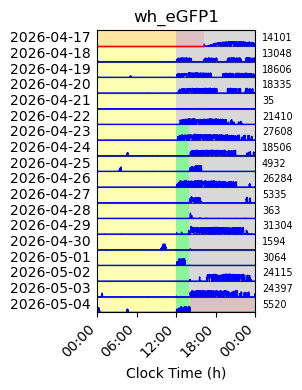

  Saved wh_eGFP2 actigram


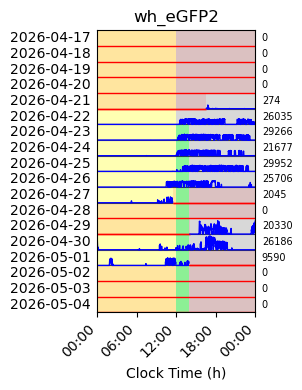

  Saved wh_eGFP3 actigram


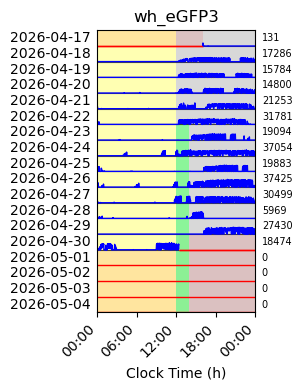

  Saved wh_eGFP4 actigram


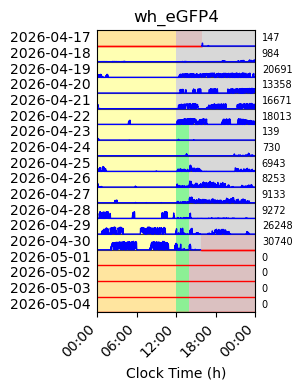

  Saved wh_eGFP5 actigram


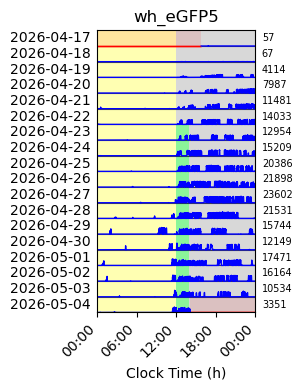

  Saved wh_eGFP6 actigram


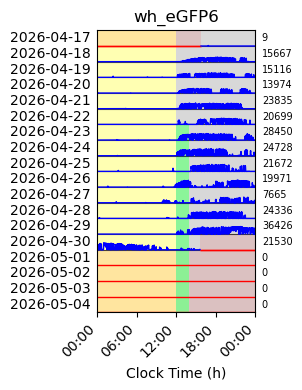

  Saved wh_eGFP7 actigram


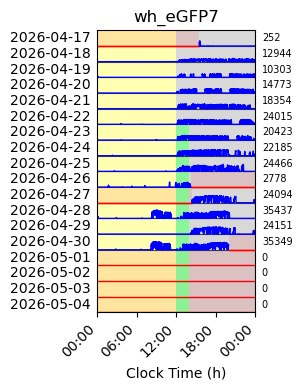


Actigrams saved to output_actigrams_CST


In [28]:
output_dir_cst = Path('output_actigrams_CST')
output_dir_cst.mkdir(parents=True, exist_ok=True)

with PdfPages(output_dir_cst / 'wheel_actigrams_CST.pdf') as pdf:
    for wheel_name in dfs_cst.keys():
        ax = plot_actigram(
            dfs_cst[wheel_name],
            wheel_name,
            show_daily_total=True,
            cage_changes=[],
            surgery_periods=surgery_periods,
            aba_dates=ABA_DATES,
            figsize=(3.2, 4),
        )

        safe_name = sanitize_filename(wheel_name)
        png_path = output_dir_cst / f"{safe_name}_actigram_CST.png"
        ax.figure.savefig(png_path, bbox_inches='tight', dpi=300)
        print(f"  Saved {wheel_name} actigram")

        pdf.savefig(ax.figure)
        plt.show()
        plt.close(ax.figure)

print(f"\nActigrams saved to {output_dir_cst}")